# T-maze

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* T-maze
* Agent navigation is largely fixed based on a randomly selected target arm for each trajectory.
* Target object initially located near end of one arm.
* Two-compartment pyramidal neuron layer:
  * Somatic input: jittered, but uniformly distributed Gaussian place cells (plastic)
  * Dendritic input: Target object-encoding cell (fixed)
  * Filtered dendritic self-inhibition
  * 1 pyramidal neuron only
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [9]:
import copy
import importlib
from pathlib import Path
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import ext_util, learn_util, plot_util, params_util

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "t_maze"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## 1. Initial target location

In [5]:
env_params = params_util.get_env_params(
    environment="tmaze",
)

agent_params = params_util.get_agent_params(
    environment="tmaze", left_arm_prop=1,
)

PC_params = params_util.get_PC_params(
    environment="tmaze", 
    place_cell_centres="uniform", #"uniform_jitter"
)

Pyr_params = params_util.get_Pyr_params(
    n=1, 
    environment="tmaze",
    log_BTSP=True,
)

 20%|███████▌                              | 1601/8000 [00:03<00:14, 457.00it/s]

BTSP event recorded at step 1523 (45.69 sec).


 29%|██████████▉                           | 2296/8000 [00:05<00:12, 438.81it/s]

BTSP update applied at step 2217 (66.51 sec).


100%|██████████████████████████████████████| 8000/8000 [00:18<00:00, 439.04it/s]


Finishing last trajectory.


756it [00:01, 386.23it/s]


Only reached target 7 times (target: 10).
Trajectory lengths (12) to date: 21.89 +/- 6.93 sec each
Trajectory lengths (12) to date: 729.75 +/- 231.07 steps each
1 BTSP event triggered (allowed from steps 0 to 8756): occurred at step 1523.


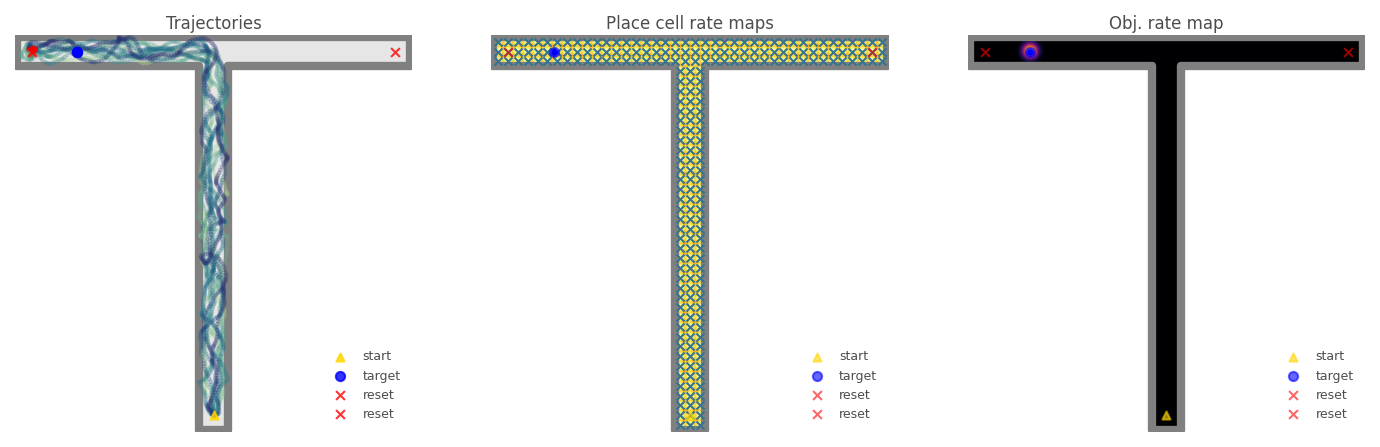

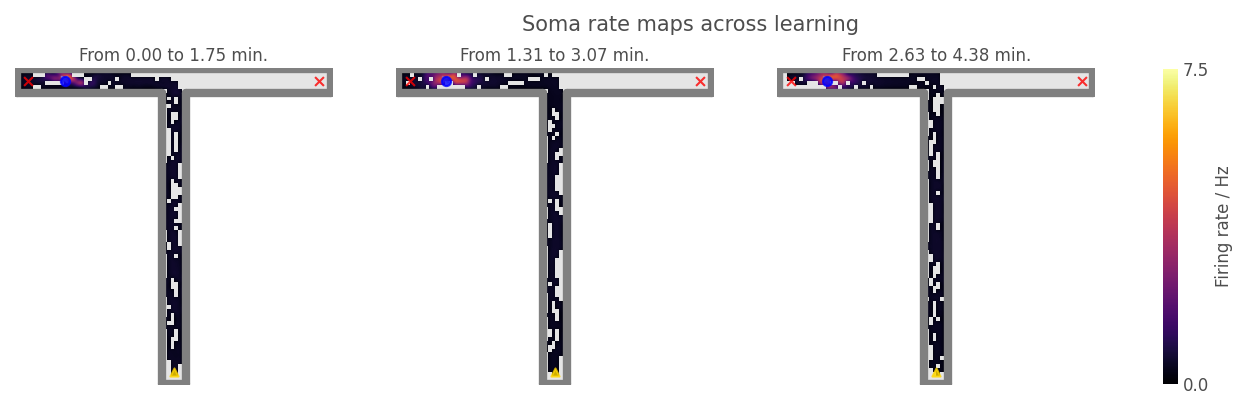

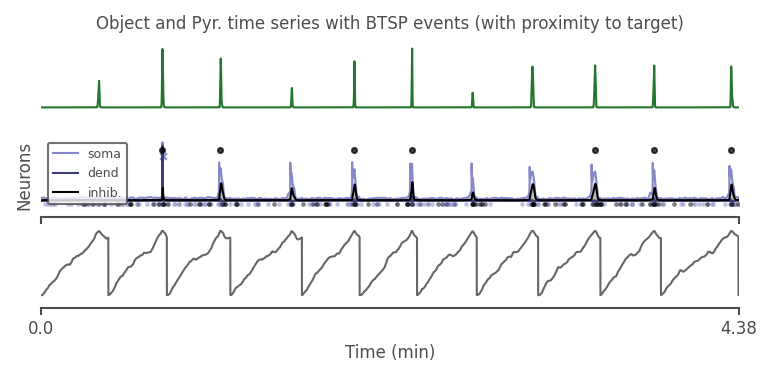

In [6]:
learner, spatial_axes, rate_maps_axes, BTSP_sub_ax = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params, 
    max_num_target_reaches=10,
    max_num_steps=8000, 
    use_Hebbian=False,
    BTSP_on=0,
)

Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(learner.Pyrs)

ALL_FIGURES["1-initial_spatial"] = spatial_axes
ALL_FIGURES["1-initial_rate_maps"] = rate_maps_axes
ALL_FIGURES["1-initial_BTSP_proximity"] = BTSP_sub_ax

Linear speed mean: 25.61 cm/s, std: 10.41 cm/s.


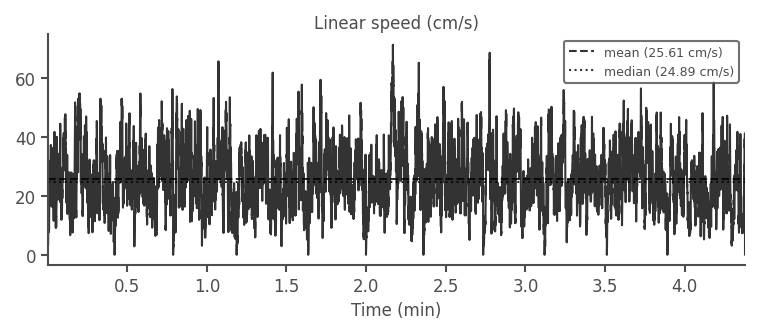

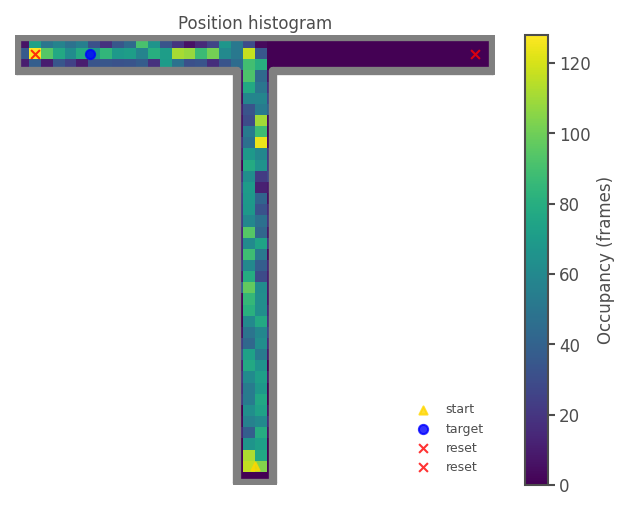

In [7]:
learner.Agent.log_speed_stats()
sub_ax_speed = learner.Agent.plot_speed(mark_mean=True, mark_median=True)
sub_ax_occ = learner.Agent.plot_occupancy()

ALL_FIGURES["1-initial_speed"] = sub_ax_speed
ALL_FIGURES["1-initial_occupancy"] = sub_ax_occ

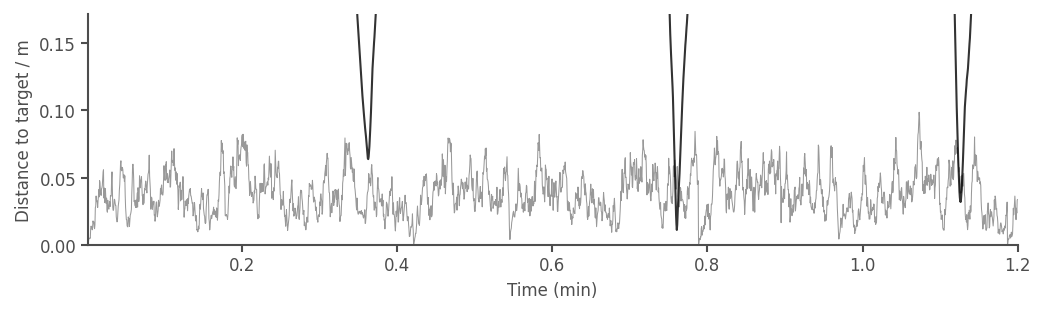

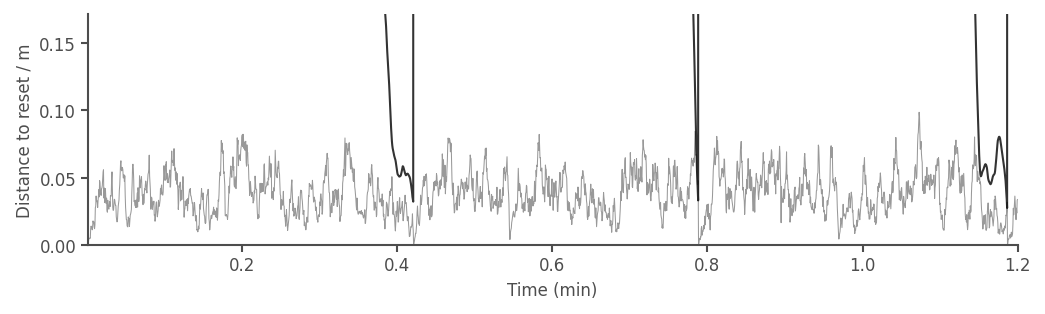

In [8]:
zoom_prop = 1.6
time_max = 1.2

sub_ax_target = learner.Agent.plot_distance_to(zoom_prop=zoom_prop)
sub_ax_reset = learner.Agent.plot_distance_to(
    zoom_prop=zoom_prop,
    position=learner.Agent.reset_position[0], 
    position_name="reset",
    tol_prop_to_speed_dt=learner.Agent.reset_reached_within_tol_prop_to_speed_dt
)
sub_ax_target.set_xlim(None, time_max)
sub_ax_reset.set_xlim(None, time_max)

ALL_FIGURES["1-initial_distance_to_target"] = sub_ax_target
ALL_FIGURES["1-initial_distance_to_reset"] = sub_ax_reset

In [9]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
learner.Pyrs.SomaCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 696.00 steps (20.88 sec.)
No neuron had at least two BTSP events triggered.


### Place cell rate maps

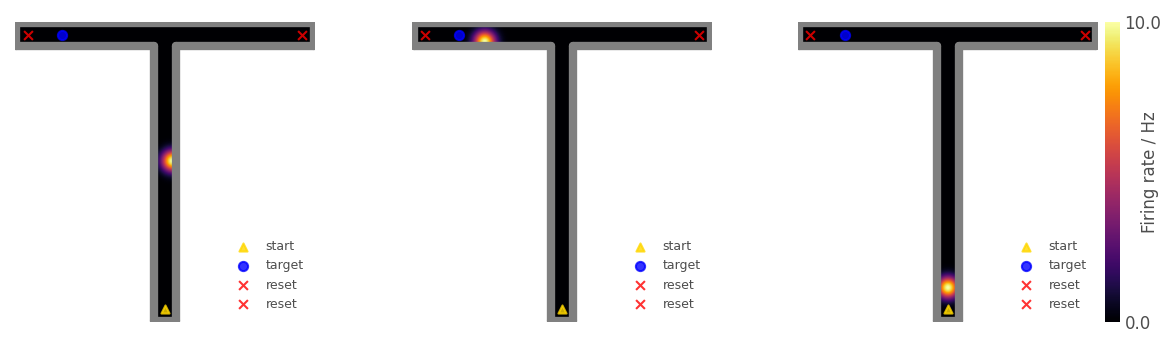

In [10]:
num_plots = 3
chosen_neurons = np.random.choice(learner.PCs.n, 3, replace=False)
_, ax1D = plt.subplots(1, num_plots, figsize=(num_plots * 2.5, 2))
learner.PCs.plot_rate_map(chosen_neurons=chosen_neurons, ax=ax1D)

ALL_FIGURES["1-initial_PC_rate_maps"] = ax1D

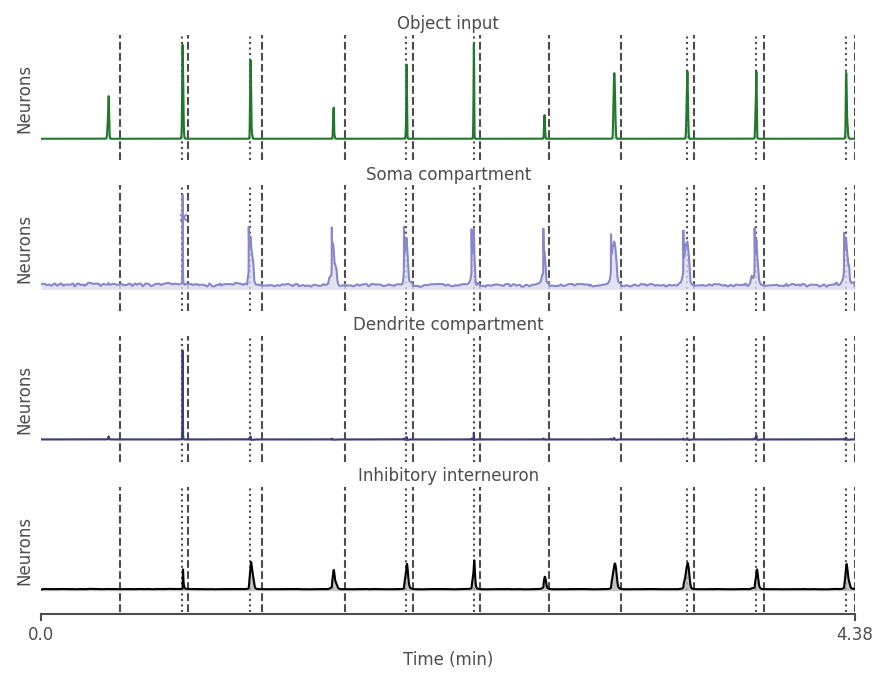

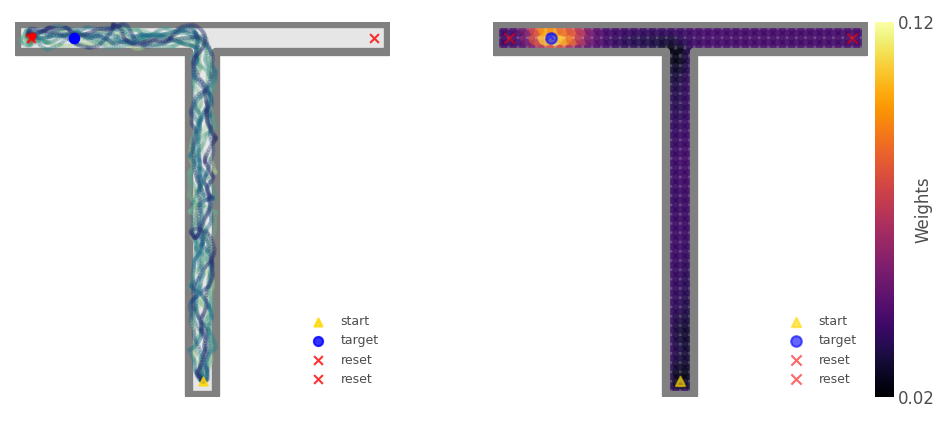

In [11]:
_, ax1D_time = plt.subplots(4, 1, figsize=[7, 5], sharex=True)

learner.Objs.plot_rate_timeseries(sub_ax=ax1D_time[0])
ax1D_time[0].set_title("Object input")
plot_util.clear_bottom(ax1D_time[0])
plot_fcts.mark_target_and_reset_points(learner.Objs, sub_ax=ax1D_time[0])

learner.Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max", ax=ax1D_time[1:])

fig, ax1D = plt.subplots(1, 2, figsize=[6, 2.5])
learner.Agent.plot_trajectories(scale_cmap_per=False, s_2D=5, alpha=0.3, sub_ax=ax1D[0])
plot_fcts.plot_2D_input_place_cell_weights(learner.Pyrs.SomaCompartment, ax=ax1D[1], s=60, plot_BTSP_events=True)

ALL_FIGURES["1-initial_timeseries"] = ax1D_time
ALL_FIGURES["1-initial_trajectory_weights"] = ax1D

## Theoretical kernel

/home/cgillon/homedir/predhpc/predhpc/util/learn_util.py:817: UserWarning: Assessment will assume geodesic wall geometry even though place cell wall geometry is line_of_sight.
  warnings.warn(


Update 1 regul.: 0.8089 (w)


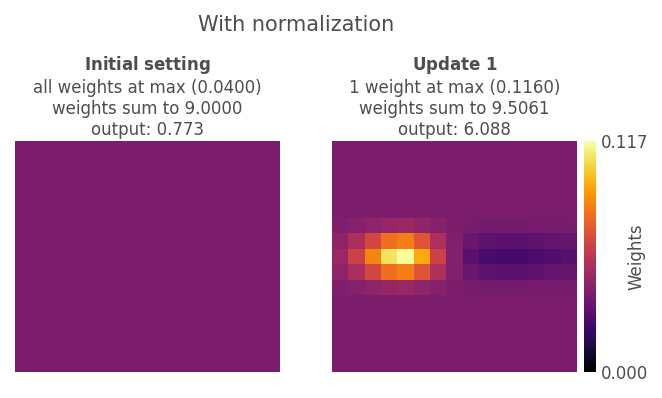

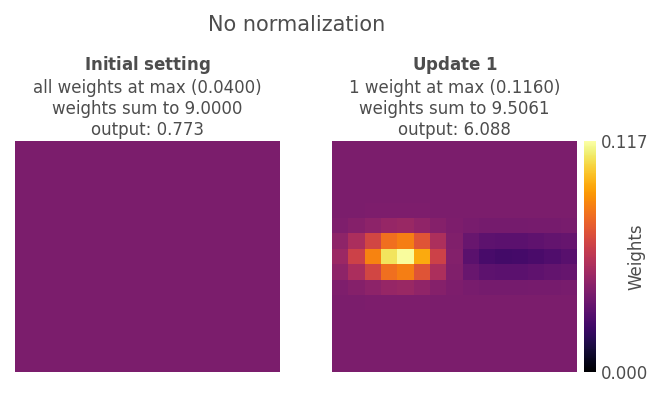

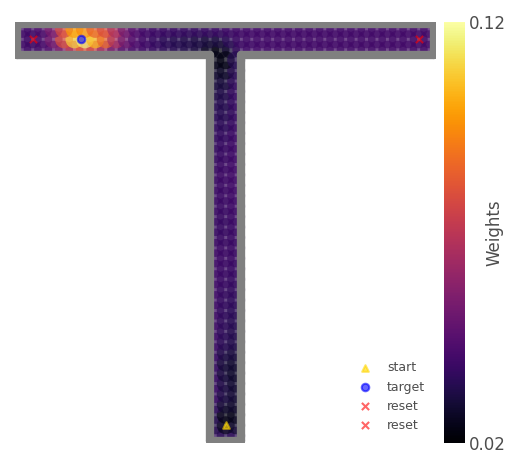

In [12]:
norm_theor_axes, no_norm_theor_axes, act_sub_ax = plot_fcts.compare_theoretical_and_true_weights(
    learner.Pyrs.SomaCompartment,
    output_fr=4.2, # tuned to match actual weights
)

ALL_FIGURES["BTSP_kernel_norm"] = norm_theor_axes
ALL_FIGURES["BTSP_kernel"] = no_norm_theor_axes
ALL_FIGURES["1-initial_actual_weights"] = act_sub_ax

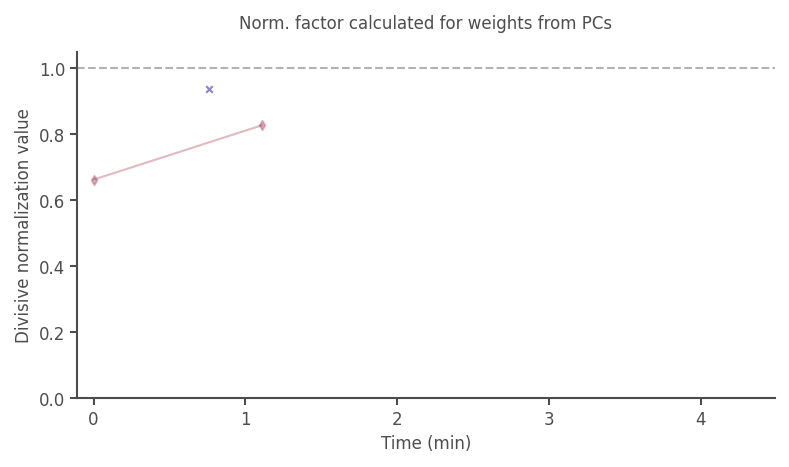

In [13]:
if learner.Pyrs.SomaCompartment.normalize_weights_divisively:
    sub_ax = learner.Pyrs.SomaCompartment.plot_normalization_values_over_time(input_layer="PCs")
    ALL_FIGURES["1-initial_weight_norm_time"] = sub_ax

BTSP events applied after 696.00 steps (20.88 sec.) (num steps: 696).


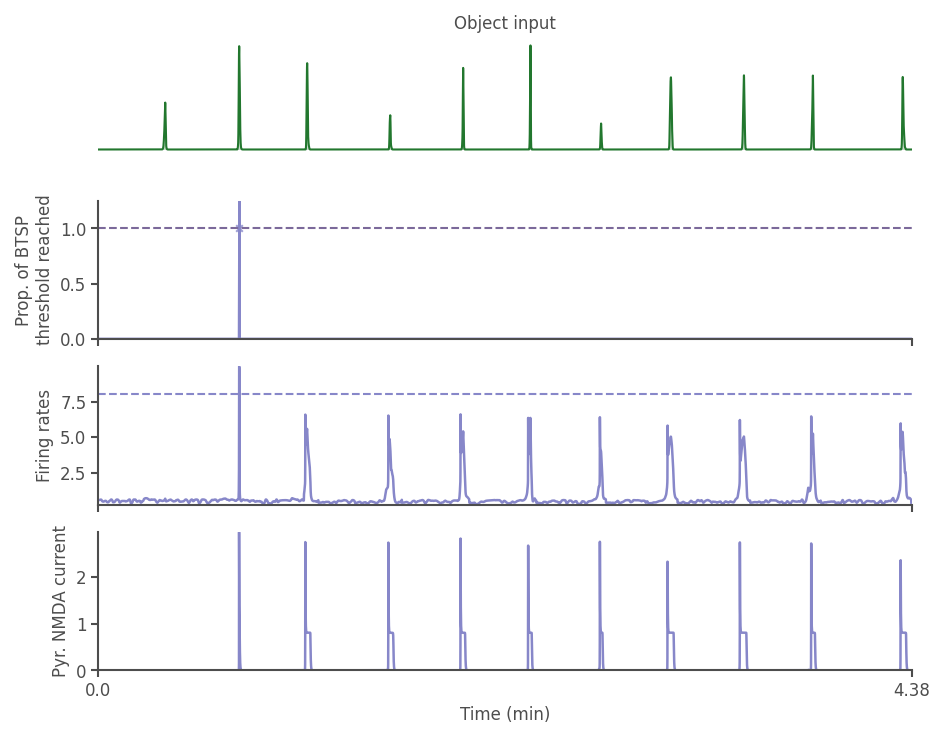

In [14]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()

fig, ax1D = plt.subplots(4, 1, figsize=[7, 5.5], sharex=True)

Objs.plot_rate_timeseries(sub_ax=ax1D[0])
ax1D[0].set_title("Object input")
ax1D[0].set_ylabel("")
plot_util.clear_bottom(ax1D[0])

learner.Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D[1:])

ALL_FIGURES["1-initial_BTSP_timeseries"] = ax1D

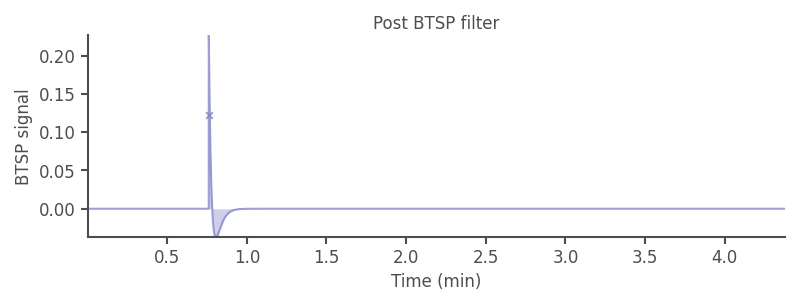

In [15]:
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["1-initial_post_BTSP_filter"] = sub_ax

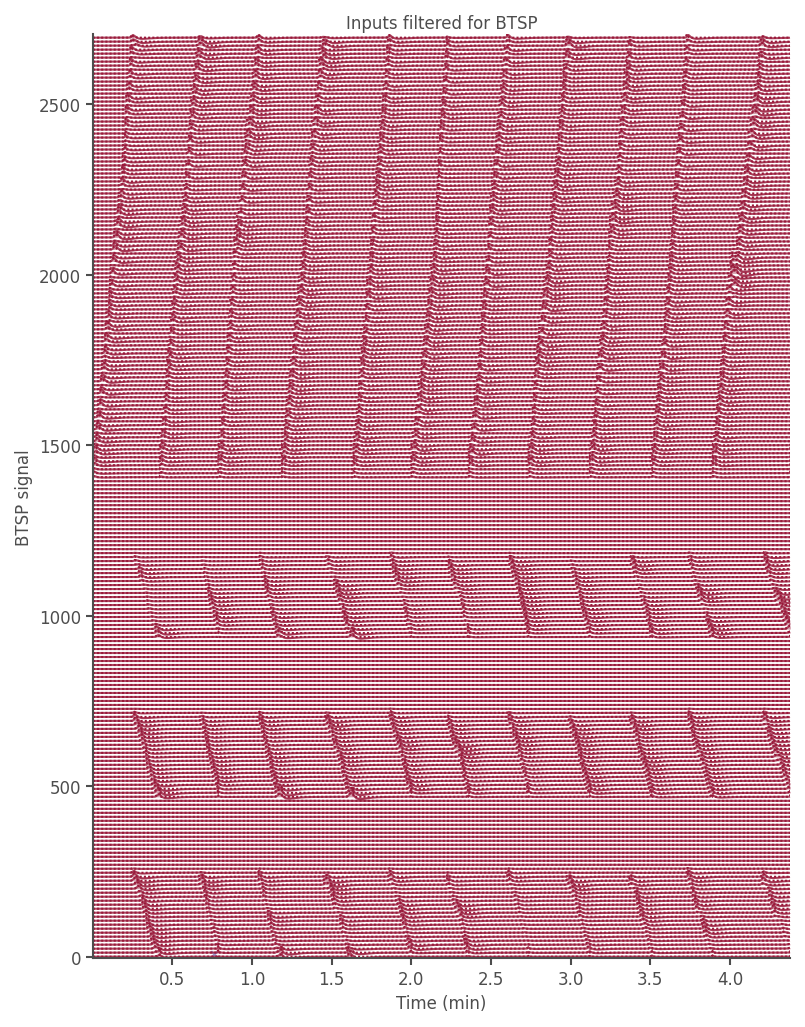

In [16]:
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP("PCs", rasterize_shading=True)
ALL_FIGURES["1-initial_pre_BTSP_filter"] = sub_ax

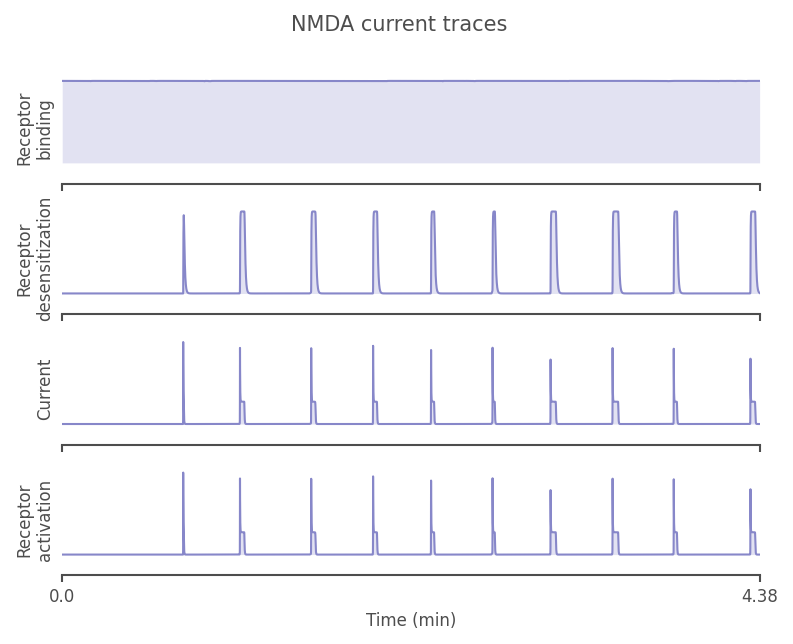

In [17]:
ax1D = learner.Pyrs.SomaCompartment.inputs["NMDACurrent"]["layer"].plot_timeseries(datatypes="all")
ALL_FIGURES["1-initial_NMDA_current"] = ax1D

In [18]:
learner.Agent.target_df

,target_arm,position_x,position_y,set_step,set_time,reached_step,reached_time,num_steps_total,time_total
0,left,0.6125,3.85,0,0.00,1516.0,45.48,1516.0,45.48
1,left,0.6125,3.85,1516,45.48,2247.0,67.41,731.0,21.93
2,left,0.6125,3.85,2247,67.41,3929.0,117.87,1682.0,50.46
3,left,0.6125,3.85,3929,117.87,4653.0,139.59,724.0,21.72
4,left,0.6125,3.85,4653,139.59,6954.0,208.62,2301.0,69.03
5,left,0.6125,3.85,6954,208.62,7695.0,230.85,741.0,22.23
6,left,0.6125,3.85,7695,230.85,8661.0,259.83,966.0,28.98
7,left,0.6125,3.85,8661,259.83,NaN,NaN,NaN,NaN


In [19]:
learner.Agent.trajectory_df

,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.998385,0.143980,0,0.00,0.143519,3.873471,841.0,25.23,841.0,25.23
1,1.994002,0.152631,841,25.23,0.168908,3.873471,1576.0,47.28,735.0,22.05
2,2.001995,0.149202,1576,47.28,0.148102,3.873471,2373.0,71.19,797.0,23.91
3,2.004421,0.151774,2373,71.19,0.165121,3.873471,3272.0,98.16,899.0,26.97
4,1.996446,0.146606,3272,98.16,0.178516,3.873471,3997.0,119.91,725.0,21.75
5,2.006038,0.147900,3997,119.91,0.137335,3.873471,4718.0,141.54,721.0,21.63
6,2.002533,0.151391,4718,141.54,0.176473,3.873471,5468.0,164.04,750.0,22.50
7,1.994642,0.151540,5468,164.04,0.169922,3.873471,6239.0,187.17,771.0,23.13
8,2.003748,0.145635,6239,187.17,0.129786,3.873471,7021.0,210.63,782.0,23.46
9,2.005120,0.149898,7021,210.63,0.123659,3.873471,7781.0,233.43,760.0,22.80


## 2. Move target

In [20]:
MOVE_NEARBY = False

In [21]:
Ag = learner.Agent
Pyrs = learner.Pyrs

if MOVE_NEARBY:
    moved_target_position = Ag.move_target_position(0.18, backward=True)
else:
    moved_target_position = np.asarray([Env.scale_x / 2, Env.scale_y / 2])
    Ag.set_target_position(moved_target_position)

move_time = Ag.t

print(f"New target position: {moved_target_position}.")

New target position: [2. 2.].


In [22]:
NUM_STEPS = 5000

learner_move = run_manager.learn_T_maze_BTSP(
    Pyrs_or_learner=Pyrs,
    max_num_target_reaches=10,
    max_num_steps=5000,
    use_Hebbian=False,
    BTSP_on=0,
    plot=False,
);

 85%|████████████████████████████████▎     | 4244/5000 [00:10<00:01, 454.34it/s]

BTSP event recorded at step 12914 (387.42 sec).


 99%|█████████████████████████████████████▌| 4936/5000 [00:11<00:00, 458.52it/s]

BTSP update applied at step 13608 (408.24 sec).


100%|██████████████████████████████████████| 5000/5000 [00:11<00:00, 422.44it/s]


Finishing last trajectory.


385it [00:00, 463.36it/s]

Only reached target 4 times (target: 10).
Trajectory lengths (19) to date: 22.33 +/- 5.62 sec each
Trajectory lengths (19) to date: 744.37 +/- 187.32 steps each
1 BTSP event triggered (allowed from steps 8757 to 14142): occurred at step 12914.


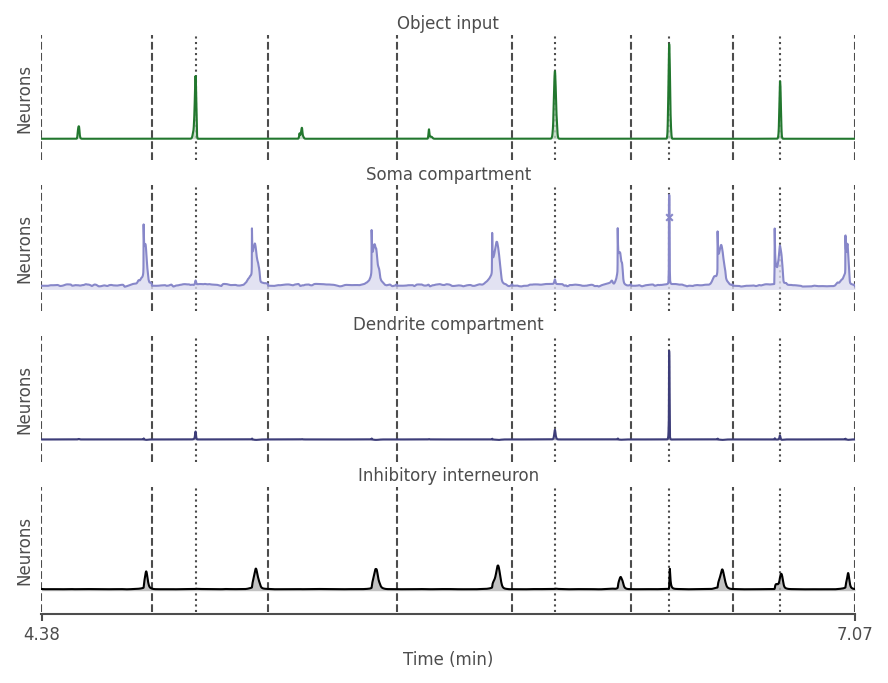

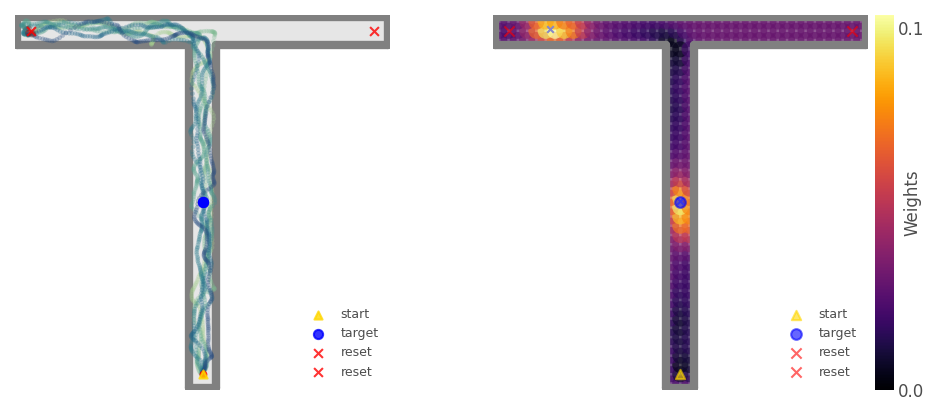

In [23]:
_, ax1D_time = plt.subplots(4, 1, figsize=[7, 5], sharex=True)
learner_move.Objs.plot_rate_timeseries(t_start=move_time, sub_ax=ax1D_time[0])
ax1D_time[0].set_title("Object input")
plot_util.clear_bottom(ax1D_time[0])
plot_fcts.mark_target_and_reset_points(learner_move.Objs, sub_ax=ax1D_time[0])

learner_move.Pyrs.plot_rate_timeseries(t_start=move_time, separate_axes=True, norm_by="shared_max", ax=ax1D_time[1:])

fig, ax1D = plt.subplots(1, 2, figsize=[6, 2.5])
learner_move.Agent.plot_trajectories(t_start=move_time, scale_cmap_per=False, s_2D=5, alpha=0.3, sub_ax=ax1D[0])
plot_fcts.plot_2D_input_place_cell_weights(learner_move.Pyrs.SomaCompartment, ax=ax1D[1], s=60, plot_BTSP_events=True)

ALL_FIGURES["2-moved_timeseries"] = ax1D_time
ALL_FIGURES["2-moved_trajectory_weights"] = ax1D

BTSP events applied after 696.00 steps (20.88 sec.) (num steps: 696, 696).


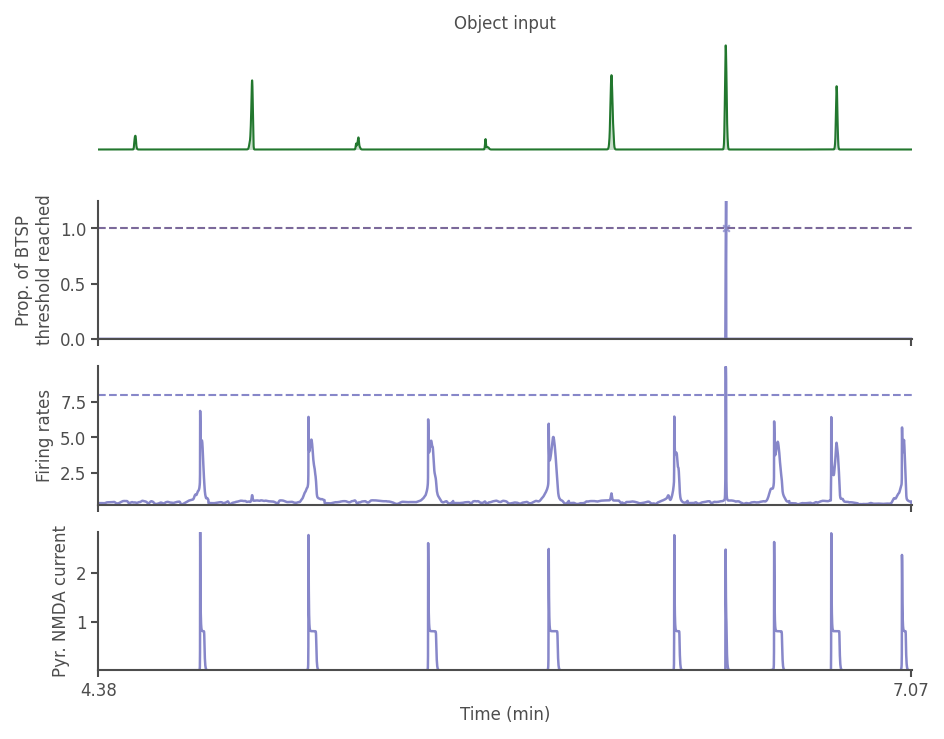

In [24]:
learner_move.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()

fig, ax1D = plt.subplots(4, 1, figsize=[7, 5.5], sharex=True)
Objs.plot_rate_timeseries(sub_ax=ax1D[0], t_start=move_time)
ax1D[0].set_title("Object input")
ax1D[0].set_ylabel("")
plot_util.clear_bottom(ax1D[0])

learner_move.Pyrs.SomaCompartment.plot_BTSP_ramp(t_start=move_time, axes=ax1D[1:])

ALL_FIGURES["2-moved_BTSP_timeseries"] = ax1D

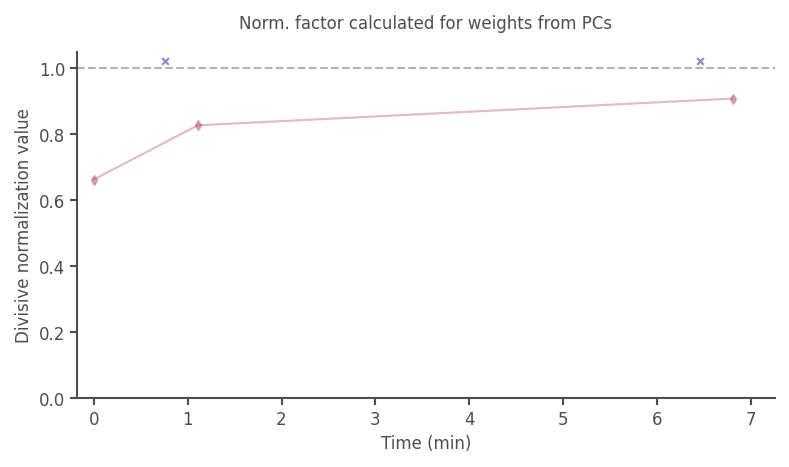

In [25]:
if learner_move.Pyrs.SomaCompartment.normalize_weights_divisively:
    sub_ax = learner_move.Pyrs.SomaCompartment.plot_normalization_values_over_time(input_layer="PCs")
    ALL_FIGURES["2-moved_weight_norm_time"] = sub_ax

## 3. Test inhibition hyperparameter

### a. Insufficient dendritic self-inhibition
Multiple BTSP events is similar locations

In [26]:
LOW_INHIBIT_WEIGHT = 0.4

Pyr_params_low = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    inhibit_weight=LOW_INHIBIT_WEIGHT,
    log_BTSP=True,
)

 55%|████████████████████▉                 | 3308/6000 [00:07<00:05, 455.48it/s]

BTSP event recorded at step 3238 (97.14 sec).


 67%|█████████████████████████▎            | 3999/6000 [00:09<00:04, 457.89it/s]

BTSP update applied at step 3932 (117.96 sec).


 83%|███████████████████████████████▌      | 4976/6000 [00:11<00:02, 458.00it/s]

...

BTSP update applied at step 6322 (189.66 sec).


646it [00:01, 453.92it/s]

BTSP event recorded at step 6594 (197.82 sec).


825it [00:02, 322.55it/s]


Only reached target 4 times (target: 12).
Trajectory lengths (9) to date: 22.75 +/- 8.95 sec each
Trajectory lengths (9) to date: 758.44 +/- 298.25 steps each
4 BTSP events triggered (allowed from steps 0 to 6825): occurred between steps 3238 and 6594, inclusively.


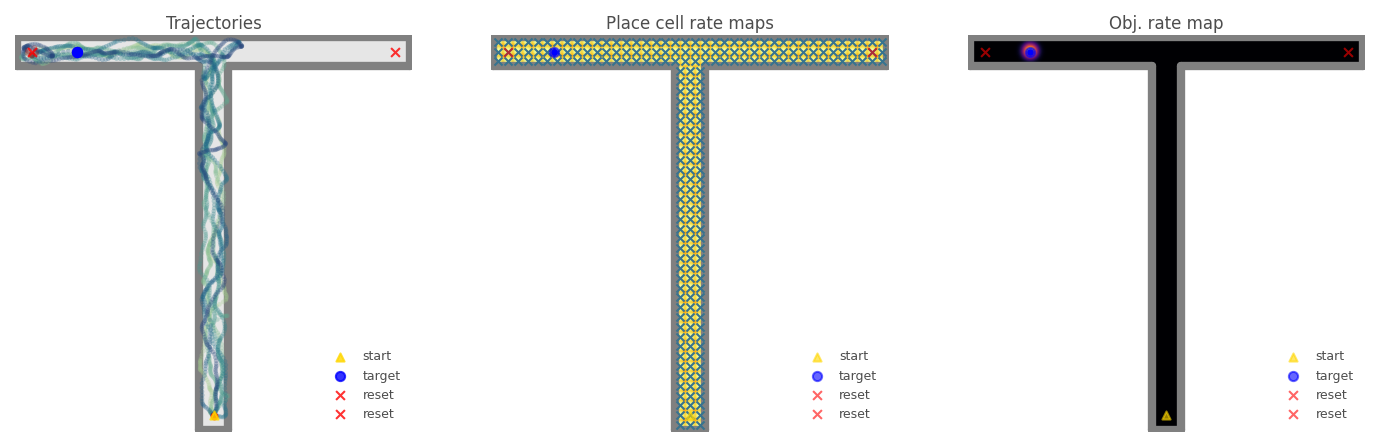

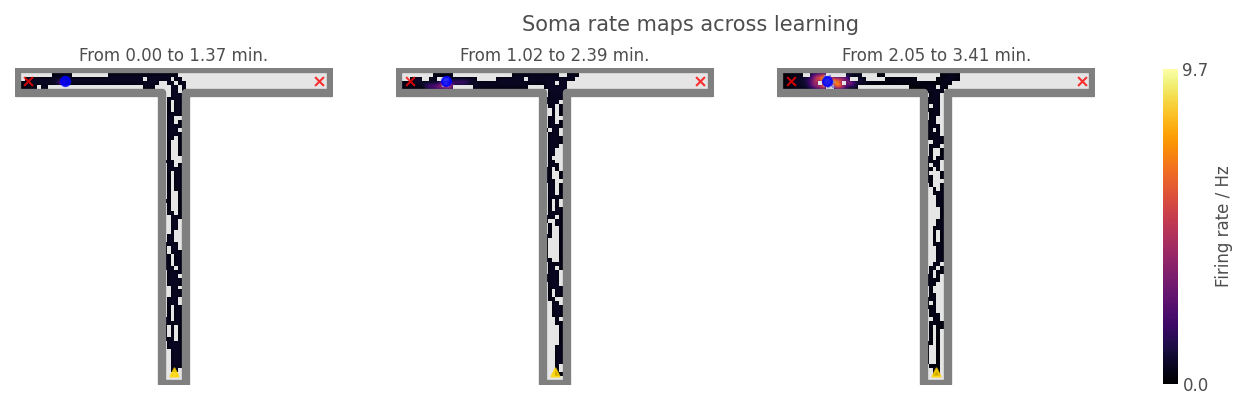

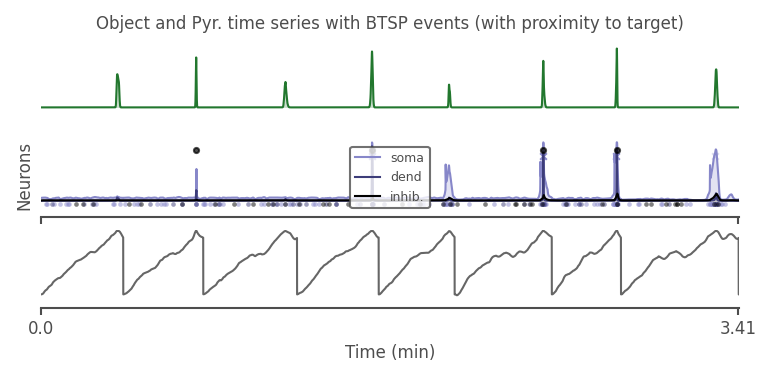

In [27]:
learner_low, spatial_axes, rate_maps_axes, BTSP_sub_ax = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params_low, 
    max_num_target_reaches=12, 
    max_num_steps=6000,
    use_Hebbian=False,
)

ALL_FIGURES["3-low_inhib_spatial"] = spatial_axes
ALL_FIGURES["3-low_inhib_rate_maps"] = rate_maps_axes
ALL_FIGURES["3-low_inhib_BTSP_proximity"] = BTSP_sub_ax

BTSP events applied after 696.00 steps (20.88 sec.) (num steps: 696, 696, 696).


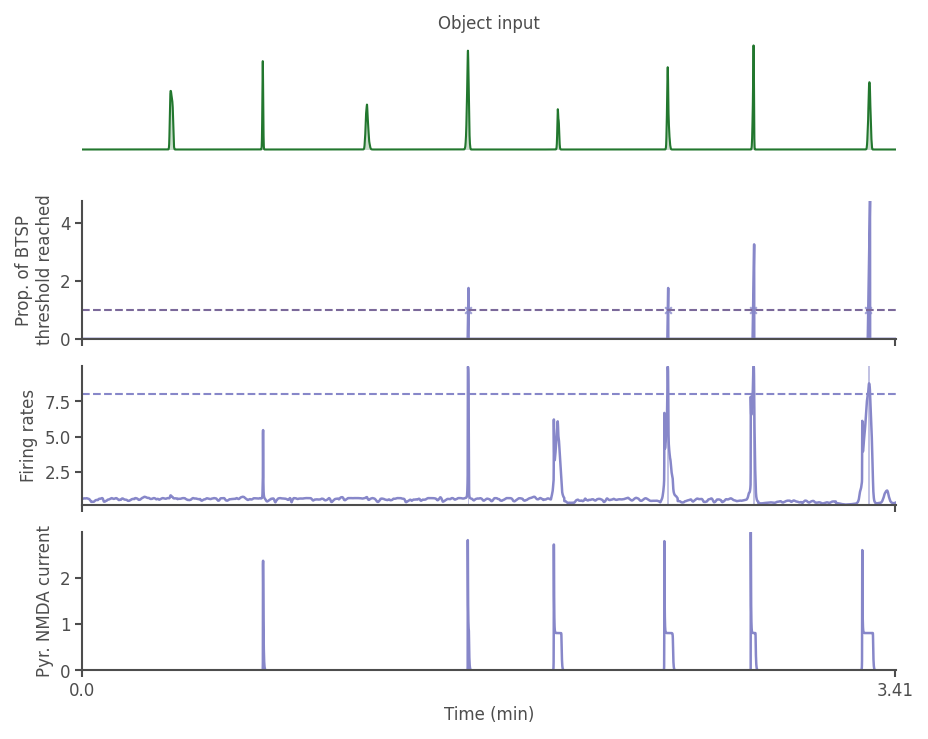

In [28]:
learner_low.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()

fig, ax1D = plt.subplots(4, 1, figsize=[7, 5.5], sharex=True)
learner_low.Objs.plot_rate_timeseries(sub_ax=ax1D[0])
ax1D[0].set_title("Object input")
ax1D[0].set_ylabel("")
plot_util.clear_bottom(ax1D[0])

learner_low.Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D[1:])

ALL_FIGURES["3-low_inhib_BTSP_timeseries"] = ax1D

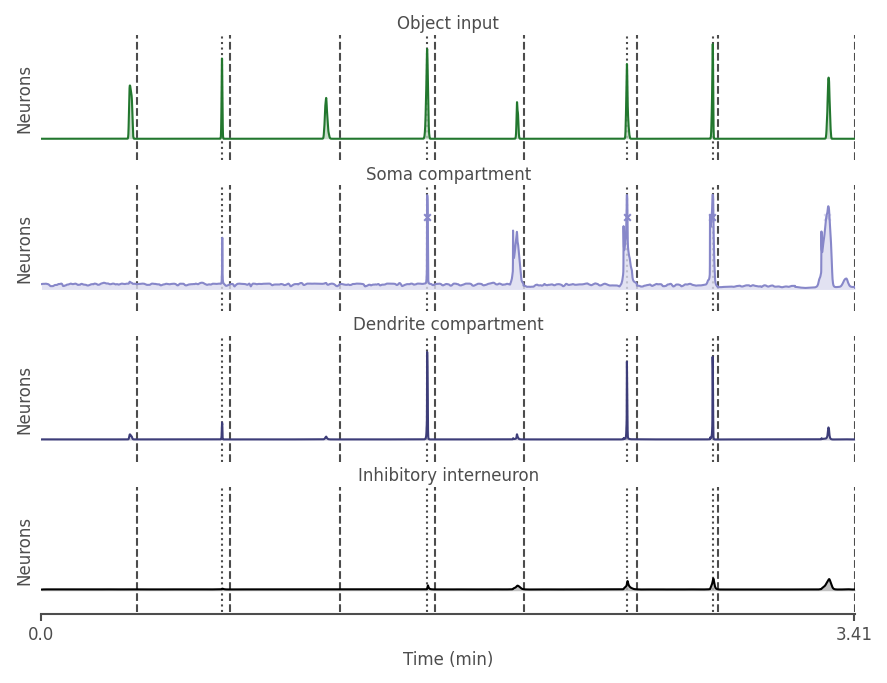

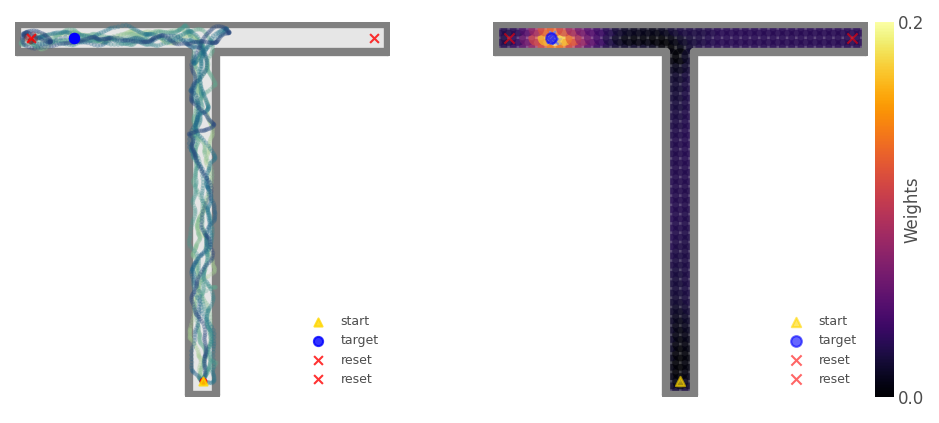

In [29]:
_, ax1D_time = plt.subplots(4, 1, figsize=[7, 5], sharex=True)

learner_low.Objs.plot_rate_timeseries(sub_ax=ax1D_time[0])
ax1D_time[0].set_title("Object input")
plot_util.clear_bottom(ax1D_time[0])
plot_fcts.mark_target_and_reset_points(learner_low.Objs, sub_ax=ax1D_time[0])

learner_low.Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max", ax=ax1D_time[1:])

fig, ax1D = plt.subplots(1, 2, figsize=[6, 2.5])
learner_low.Agent.plot_trajectories(scale_cmap_per=False, s_2D=5, alpha=0.3, sub_ax=ax1D[0])
plot_fcts.plot_2D_input_place_cell_weights(learner_low.Pyrs.SomaCompartment, ax=ax1D[1], s=60, plot_BTSP_events=True)

ALL_FIGURES["3-low_inhib_timeseries"] = ax1D_time
ALL_FIGURES["3-low_inhib_trajectory_weights"] = ax1D

### b. Excess dendritic self-inhibiton
BTSP is unlikely to occur.

In [30]:
HIGH_INHIBIT_WEIGHT = 2.0

Pyr_params_high = params_util.get_Pyr_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    inhibit_weight=HIGH_INHIBIT_WEIGHT,
    log_BTSP=True,
)

100%|██████████████████████████████████████| 6000/6000 [00:14<00:00, 428.13it/s]


Finishing last trajectory.


298it [00:00, 453.99it/s]


Only reached target 4 times (target: 12).
Trajectory lengths (9) to date: 21.00 +/- 7.51 sec each
Trajectory lengths (9) to date: 699.89 +/- 250.18 steps each
0 BTSP events triggered (allowed from steps 0 to 6298).


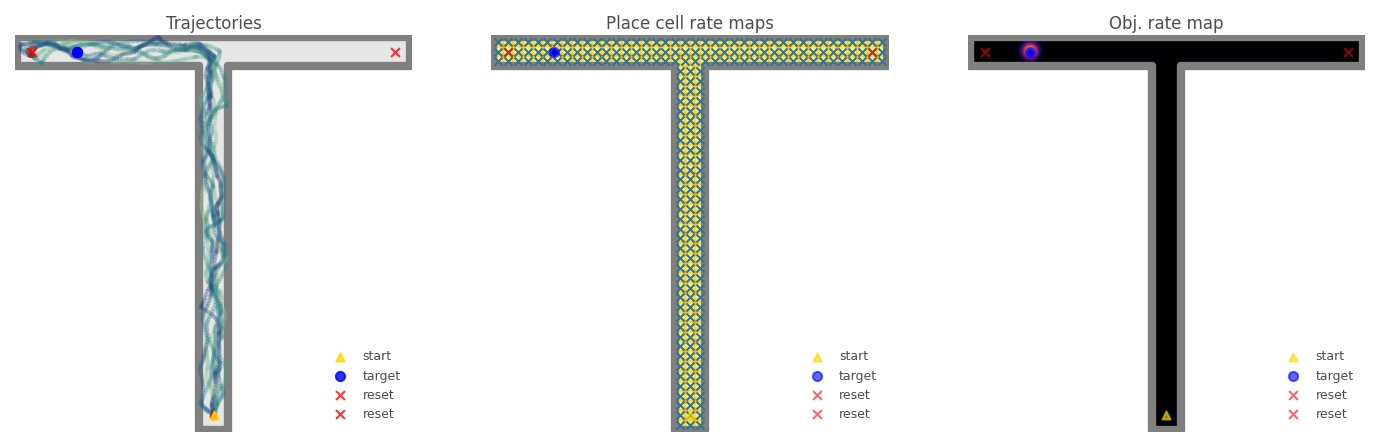

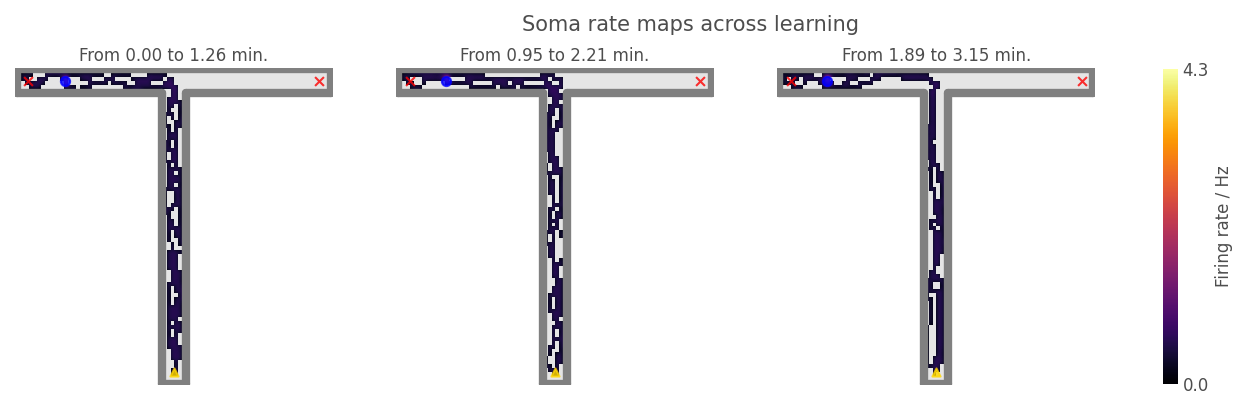

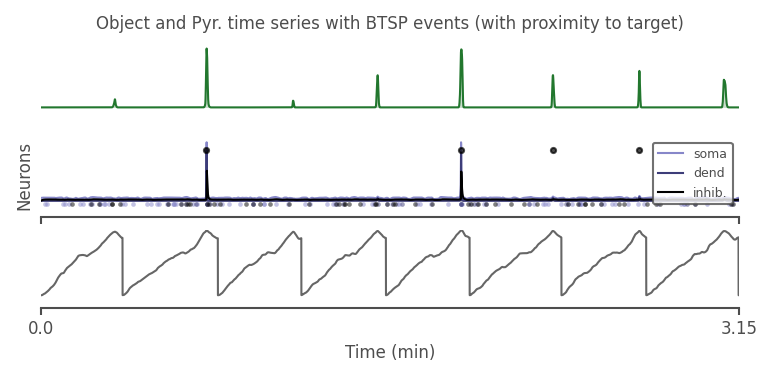

In [31]:
learner_high, spatial_axes, rate_maps_axes, BTSP_sub_ax = run_manager.learn_T_maze_BTSP(
    env_params=env_params, 
    agent_params=agent_params, 
    PC_params=PC_params, 
    Pyr_params=Pyr_params_high, 
    max_num_target_reaches=12, 
    max_num_steps=6000,
    use_Hebbian=False,
)

ALL_FIGURES["4-high_inhib_spatial"] = spatial_axes
ALL_FIGURES["4-high_inhib_rate_maps"] = rate_maps_axes
ALL_FIGURES["4-high_inhib_BTSP_proximity"] = BTSP_sub_ax

No BTSP events applied.


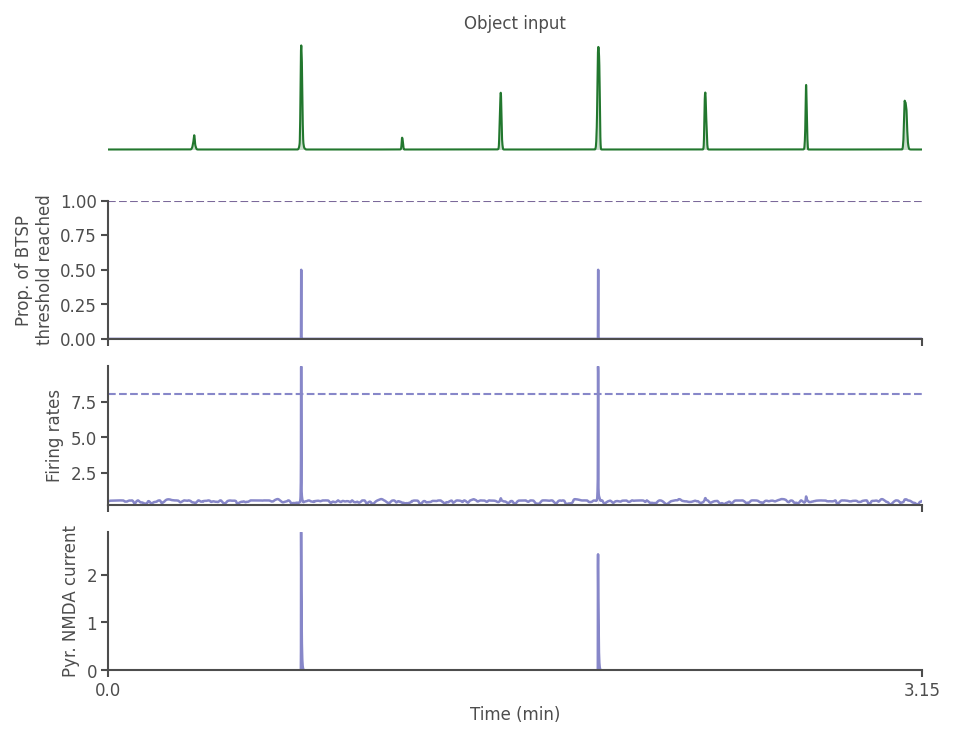

In [32]:
learner_high.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()

fig, ax1D = plt.subplots(4, 1, figsize=[7, 5.5], sharex=True)
learner_high.Objs.plot_rate_timeseries(sub_ax=ax1D[0])
ax1D[0].set_title("Object input")
ax1D[0].set_ylabel("")
plot_util.clear_bottom(ax1D[0])

learner_high.Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D[1:])

ALL_FIGURES["4-high_inhib_BTSP_timeseries"] = ax1D

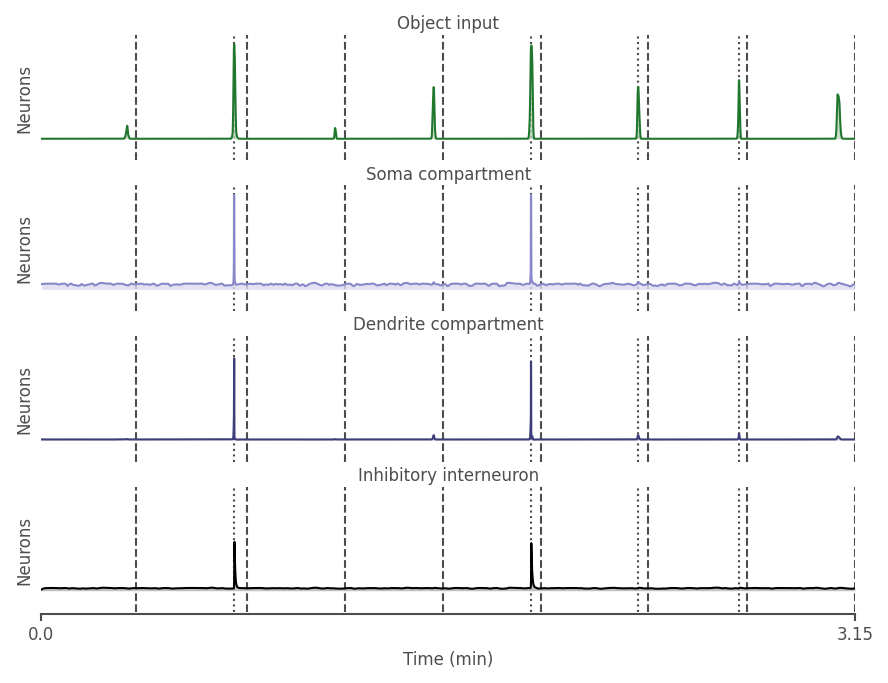

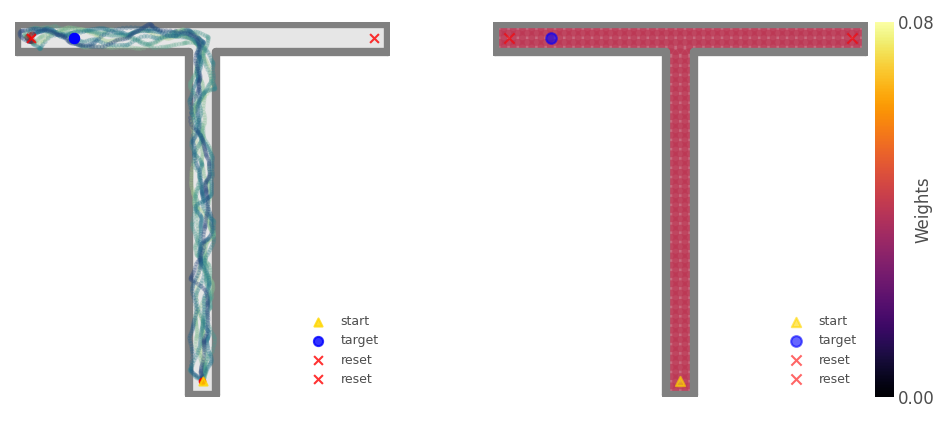

In [33]:
_, ax1D_time = plt.subplots(4, 1, figsize=[7, 5], sharex=True)

learner_high.Objs.plot_rate_timeseries(sub_ax=ax1D_time[0])
ax1D_time[0].set_title("Object input")
plot_util.clear_bottom(ax1D_time[0])
plot_fcts.mark_target_and_reset_points(learner_high.Objs, sub_ax=ax1D_time[0])

learner_high.Pyrs.plot_rate_timeseries(separate_axes=True, norm_by="shared_max", ax=ax1D_time[1:])

fig, ax1D = plt.subplots(1, 2, figsize=[6, 2.5])
learner_high.Agent.plot_trajectories(scale_cmap_per=False, s_2D=5, alpha=0.3, sub_ax=ax1D[0])
plot_fcts.plot_2D_input_place_cell_weights(learner_high.Pyrs.SomaCompartment, ax=ax1D[1], s=60, plot_BTSP_events=True)

ALL_FIGURES["4-high_inhib_timeseries"] = ax1D_time
ALL_FIGURES["4-high_inhib_trajectory_weights"] = ax1D

## 4. Save

In [34]:
SAVE = True

In [35]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, save=True)        

Saving 34 figures...
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_05_22/1-initial_spatial_1521.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_05_22/1-initial_rate_maps_1521.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_05_22/1-initial_BTSP_proximity_1521.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_05_22/1-initial_speed_1521.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_05_22/1-initial_occupancy_1521.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_05_22/1-initial_distance_to_target_1521.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_05_22/1-initial_distance_to_reset_1521.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/t_maze/25_05_22/1-initial_PC_rate_maps_1521.png  & .svg
Figure saved to /home/cgillon/homedir/pr